In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import warnings
warnings.filterwarnings("ignore")
import os


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in la

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in la

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in la

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in la

AttributeError: _ARRAY_API not found

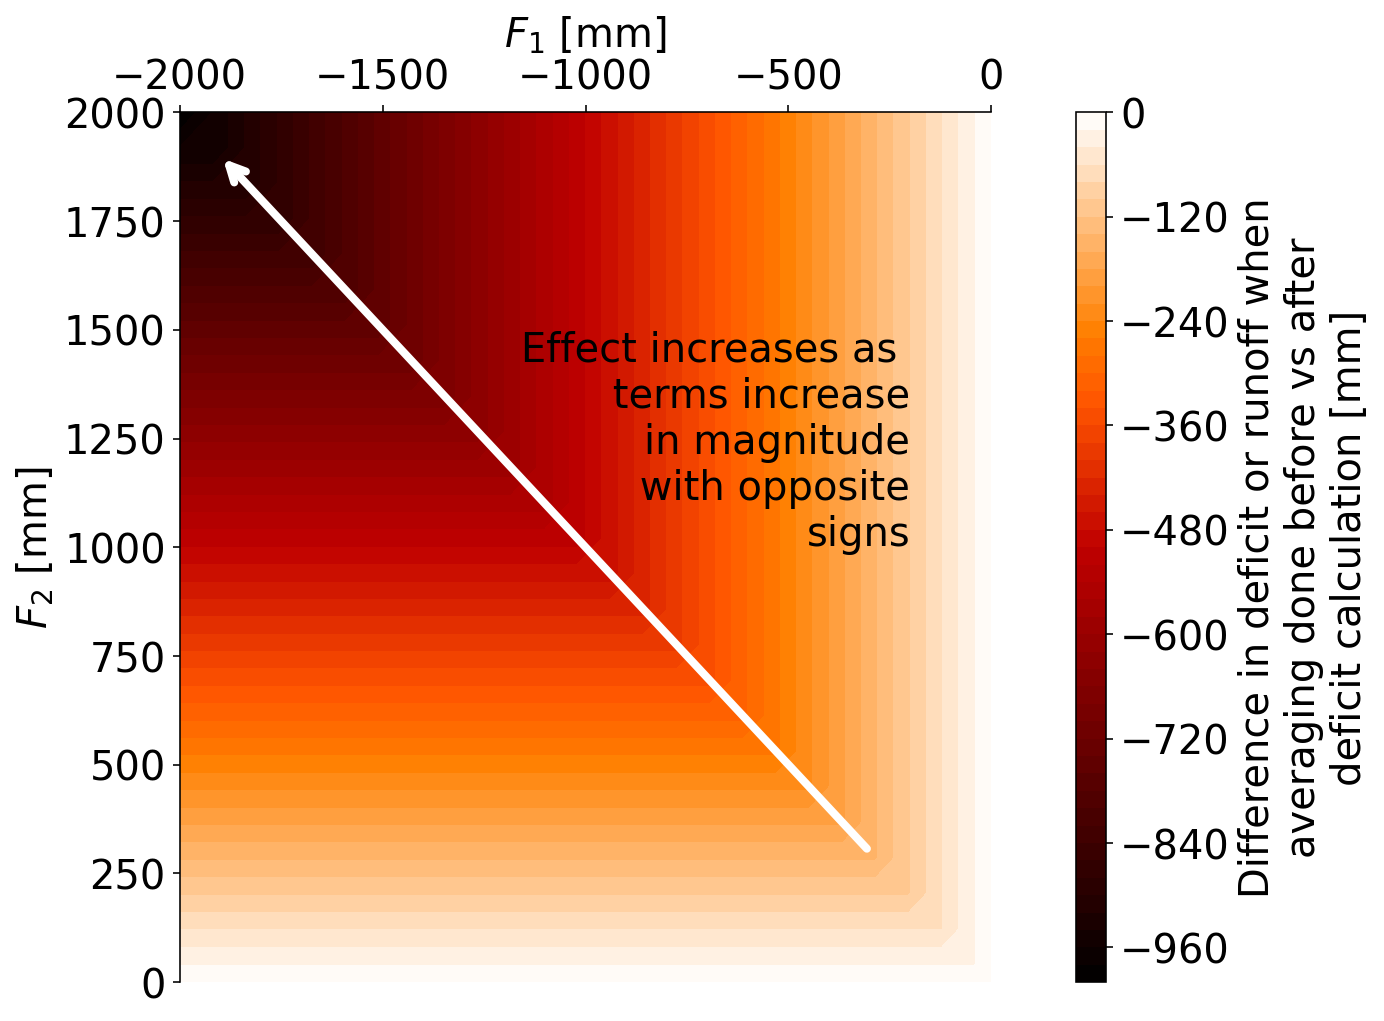

In [4]:
# plot potential difference between pixel and basin deficit/runoff

def diff_between_averagingD(A,B):
    avg_first = 0.5*(np.where(-A+-B>0,-A+-B,0))
    avg_last = 0.5*(np.where(-A>0,-A,0)+np.where(-B>0,-B,0))
    returnval = (avg_first - avg_last)
    returnval = np.where(A>B,np.nan,returnval)
    return returnval

a = b = np.linspace(-2000,2000,)#3000)

A, B = np.meshgrid(a, b)
plt.rcParams.update({'font.size': 20})
fig,axs = plt.subplots(1,2,figsize = (8.3,8),gridspec_kw = {'width_ratios':[8,.3]})

ax = axs[0]
im = ax.contourf(A,B,diff_between_averagingD(A,B),levels = 50,
                cmap='gist_heat')
cbar = plt.colorbar(im,cax = axs[1])
ax.set_title('$F_1$ [mm]',fontsize = 20)
ax.set_ylabel('$F_2$ [mm]')
cbar.set_label('Difference in deficit or runoff when\naveraging done before vs after\ndeficit calculation [mm]')
ax.annotate('',xy=(300,-300),
           xytext = (1900,-1900),
           arrowprops={'edgecolor':'white',
                      'arrowstyle':'<-',
                      'lw':4})
ax.annotate('',xy=(-300,300),
           xytext = (-1900,1900),
           arrowprops={'edgecolor':'white',
                      'arrowstyle':'<-',
                      'lw':4})

ax.text(-200,1500,'Effect increases as \n terms increase\nin magnitude\n with opposite\nsigns',
        ha='right', 
#         fontsize=16,
        va='top',
       c = 'k',)

ax.xaxis.tick_top()
ax.spines[['bottom','right']].set_visible(False)
ax.set_xlim(-2000,0)
ax.set_ylim(0,2000)

plt.savefig('averaging_impactD.png',format='png',dpi=300,bbox_inches='tight')